# Instance Segmentation with YOLO11 — Magnetic Tile Defect Detection

We have trained a detector that draws **bounding boxes** around PCB defects. Boxes tell us *where* a defect is — but not its exact shape, area, or boundary. In this session we move to **instance segmentation**: predicting a pixel-level mask for every defect instance.

By the end of this session you will have:
- Understood how PNG masks are converted into YOLO polygon format (the core data prep step)
- Trained a YOLO11n-seg model on the Magnetic Tile Defect dataset
- Evaluated per-class mask IoU and compared it with box mAP
- Analysed failure cases and connected results back to the class imbalance story

**Dataset**: [Magnetic Tile Defect](https://github.com/abin24/Magnetic-tile-defect-datasets.) — 1,344 images, 5 defect classes + defect-free  
**Model**: YOLO11n-seg (nano) pretrained on COCO, fine-tuned on Magnetic Tile  
**Citation**: Huang et al., *Surface Defect Saliency of Magnetic Tile*, The Visual Computer, 2020

---

### Expected folder layout after cloning the dataset

```
git clone https://github.com/abin24/Magnetic-tile-defect-datasets.
```

```
Magnetic-tile-defect-datasets/     ← set DATASET_ROOT below
  MT_Blowhole/
    Imgs/       ← .jpg images AND .png masks share the same folder
                ← e.g. exp1_000.jpg (image) + exp1_000.png (mask)
  MT_Crack/
    Imgs/
  MT_Break/
    Imgs/
  MT_Fray/
    Imgs/
  MT_Uneven/
    Imgs/
  MT_Free/      ← defect-free images only (.jpg, no paired .png masks)
    Imgs/
```

**Important**: there is no separate `Annotations/` folder. Each `.jpg` image
is paired with a `.png` mask of the same filename stem in the same `Imgs/` directory.


## 0. Setup

In [ ]:
#%pip install ultralytics supervision --quiet

In [2]:
import os
import tempfile

miopen_dir = tempfile.mkdtemp(prefix="miopen-", dir="/tmp")
os.environ["MIOPEN_USER_DB_PATH"] = miopen_dir
os.environ["MIOPEN_CUSTOM_CACHE_DIR"] = miopen_dir

In [3]:
import random
import shutil
from pathlib import Path

import cv2
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import supervision as sv
import torch
import yaml
from ultralytics import YOLO

In [7]:
# ── CONFIGURE THIS ──────────────────────────────────────────────────────────
DATASET_ROOT = Path("/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Segmentation/Magnetic-tile-defect-datasets.")  # ← set this
OUTPUT_ROOT  = Path("/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Segmentation/magnetic_tile_yolo")   # where prepared YOLO data will go
YAML_PATH = OUTPUT_ROOT / "data.yaml"

USERNAME = os.environ.get("USER", "unknown")
print(USERNAME)
FLASH_DIR = Path(f"/flash/project_465002387/MS_YOLO/{USERNAME}")
FLASH_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR = FLASH_DIR / "runs/segment/magnetic_tile_yolo11n"
# ────────────────────────────────────────────────────────────────────────────

assert DATASET_ROOT.exists(), f"Dataset not found at {DATASET_ROOT}"

xieruiwe


In [5]:
# ── reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── device ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# ── class definitions ───────────────────────────────────────────────────────
# MT_Free is excluded — it has no annotations and is used as background only
DEFECT_CLASSES = ["blowhole", "crack", "break", "fray", "uneven"]
CLASS_FOLDERS  = ["MT_Blowhole", "MT_Crack", "MT_Break", "MT_Fray", "MT_Uneven"]
FREE_FOLDER    = "MT_Free"
NC = len(DEFECT_CLASSES)
print(f"Defect classes ({NC}): {DEFECT_CLASSES}")

COLORS = plt.cm.tab10(np.linspace(0, 1, NC))

Using device: cuda
Defect classes (5): ['blowhole', 'crack', 'break', 'fray', 'uneven']


## 1. Exploratory Data Analysis

Before converting any data, we look at what we have: how many images per class, what the defects look like, and what the raw PNG masks look like.

### 1.1 Dataset size and class distribution

In [14]:
counts = {}
for folder, name in zip(CLASS_FOLDERS, DEFECT_CLASSES):
    img_dir = DATASET_ROOT / folder / "Imgs"
    # Count only .jpg — the paired .png masks sit in the same folder
    # and must not be counted as images
    n = len(list(img_dir.glob("*.jpg")))
    counts[name] = n
    print(f"{folder:15s} ({name:10s}): {n:4d} images")

free_dir = DATASET_ROOT / FREE_FOLDER / "Imgs"
n_free = len(list(free_dir.glob("*.jpg")))
print(f"{'MT_Free':15s} (defect-free): {n_free:4d} images")
print(f"\nTotal: {sum(counts.values()) + n_free} images")

MT_Blowhole     (blowhole  ):  115 images
MT_Crack        (crack     ):   57 images
MT_Break        (break     ):   85 images
MT_Fray         (fray      ):   32 images
MT_Uneven       (uneven    ):  103 images
MT_Free         (defect-free):  952 images

Total: 1344 images


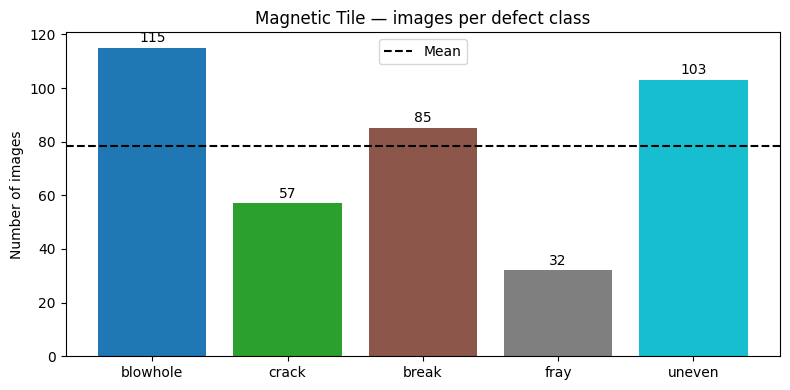

Class imbalance ratio (max/min): 3.6×


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(DEFECT_CLASSES, [counts[n] for n in DEFECT_CLASSES],
              color=COLORS)
ax.axhline(np.mean(list(counts.values())), color="black",
           linestyle="--", label="Mean")
ax.set_ylabel("Number of images")
ax.set_title("Magnetic Tile — images per defect class")
ax.legend()
ax.bar_label(bars, padding=2)
plt.tight_layout()
plt.show()

vals = list(counts.values())
print(f"Class imbalance ratio (max/min): {max(vals)/min(vals):.1f}×")

**Discussion**: Compare this imbalance with the DeepPCB dataset from this morning. Which classes do you predict will have the lowest mask IoU after training?

### 1.2 What do the defects look like?

Unlike this morning's PCB defects, magnetic tile defects are subtle — low contrast against the background. This is a key reason why segmentation (exact pixel boundary) adds more value here than bounding boxes.

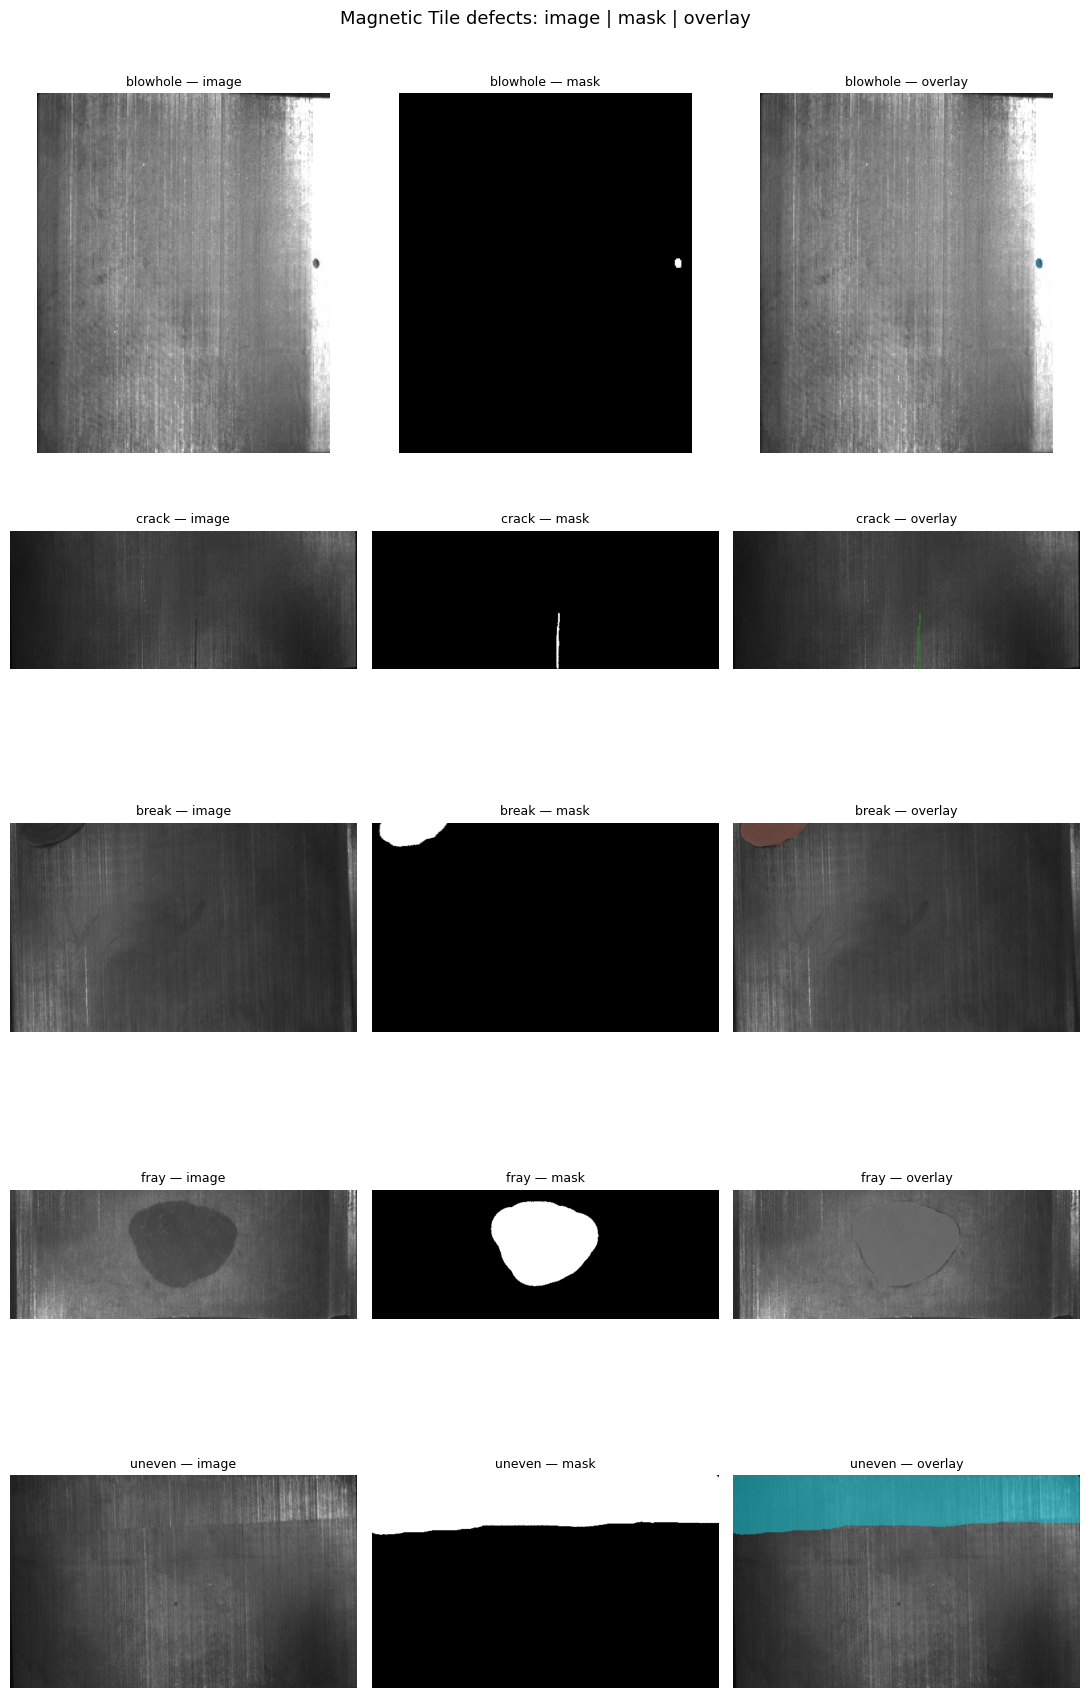

In [7]:
fig, axes = plt.subplots(NC, 3, figsize=(11, 3.5 * NC))
fig.suptitle("Magnetic Tile defects: image | mask | overlay", fontsize=13, y=1.01)

for row, (folder, name) in enumerate(zip(CLASS_FOLDERS, DEFECT_CLASSES)):
    img_dir   = DATASET_ROOT / folder / "Imgs"
    # Images are .jpg; masks are .png with the same stem, in the same folder
    jpg_imgs  = sorted(img_dir.glob("*.jpg"))
    if not jpg_imgs:
        continue
    img_path  = random.choice(jpg_imgs)
    mask_path = img_dir / (img_path.stem + ".png")

    img  = cv2.cvtColor(cv2.imread(str(img_path)),  cv2.COLOR_BGR2RGB)

    # Column 0: raw image
    axes[row][0].imshow(img, cmap="gray")
    axes[row][0].set_title(f"{name} — image", fontsize=9)
    axes[row][0].axis("off")

    if mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        # Column 1: raw mask
        axes[row][1].imshow(mask, cmap="gray")
        axes[row][1].set_title(f"{name} — mask", fontsize=9)
        axes[row][1].axis("off")

        # Column 2: overlay
        overlay = img.copy()
        overlay[mask > 127] = (
            overlay[mask > 127] * 0.4
            + np.array(COLORS[row][:3]) * 255 * 0.6
        ).astype(np.uint8)
        axes[row][2].imshow(overlay)
        axes[row][2].set_title(f"{name} — overlay", fontsize=9)
        axes[row][2].axis("off")
    else:
        axes[row][1].axis("off")
        axes[row][2].axis("off")

plt.tight_layout()
plt.show()

**Key observation**: The mask column shows exactly which pixels belong to the defect. This is what a bounding box *cannot* tell you — a box drawn around a thin crack includes mostly background pixels. The mask gives the exact defect boundary, which matters for severity scoring (area in mm²) and for distinguishing adjacent defects.

## 2. Data Preparation: PNG Mask → YOLO Polygon

This is the core pipeline of the afternoon session. YOLO-seg expects polygon annotations, not pixel masks. We convert each PNG mask to a list of normalised polygon coordinates.

The steps are:
1. Load PNG mask as grayscale
2. Find contours with `cv2.findContours`
3. Approximate each contour to a polygon with `cv2.approxPolyDP`
4. Normalise coordinates to `[0, 1]`
5. Write YOLO format: `class_id x1 y1 x2 y2 ... xn yn`

### 2.1 Understanding `cv2.findContours` and `approxPolyDP`

Let's walk through the conversion on one example image before running the full loop.

Image size: 219×264
Number of contours found: 1
Points in first contour (raw): 72
  epsilon=0.001: 62 polygon points
  epsilon=0.005: 8 polygon points
  epsilon=0.010: 6 polygon points


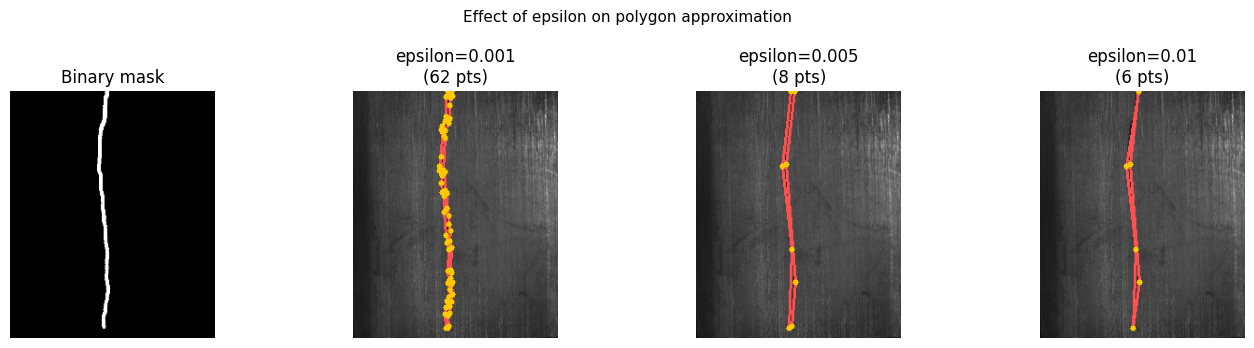

In [8]:
# Pick one example from MT_Crack (usually has clean, clear contours)
example_folder = DATASET_ROOT / "MT_Crack"
example_imgs   = sorted((example_folder / "Imgs").glob("*.jpg"))
example_img_path  = example_imgs[0]
# Mask has the same stem as the image, stored as .png in the same Imgs/ folder
example_mask_path = example_folder / "Imgs" / (example_img_path.stem + ".png")

img  = cv2.cvtColor(cv2.imread(str(example_img_path)), cv2.COLOR_BGR2RGB)
mask = cv2.imread(str(example_mask_path), cv2.IMREAD_GRAYSCALE)
h, w = mask.shape

# Step 1 — find contours
contours, _ = cv2.findContours(
    mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_KCOS
)
print(f"Image size: {w}×{h}")
print(f"Number of contours found: {len(contours)}")
print(f"Points in first contour (raw): {len(contours[0])}")

# Step 2 — approximate with different epsilon values
epsilons     = [0.001, 0.005, 0.01]
approximated = []
for eps in epsilons:
    arc   = cv2.arcLength(contours[0], True)
    approx = cv2.approxPolyDP(contours[0], eps * arc, True)
    approximated.append(approx)
    print(f"  epsilon={eps:.3f}: {len(approx)} polygon points")

# Visualise
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(mask, cmap="gray")
axes[0].set_title("Binary mask")
axes[0].axis("off")

for ax, approx, eps in zip(axes[1:], approximated, epsilons):
    vis = img.copy()
    cv2.drawContours(vis, [approx], -1, (255, 80, 80), 2)
    pts = approx.reshape(-1, 2)
    for p in pts:
        cv2.circle(vis, tuple(p), 3, (255, 200, 0), -1)
    ax.imshow(vis)
    ax.set_title(f"epsilon={eps}\n({len(approx)} pts)")
    ax.axis("off")

plt.suptitle("Effect of epsilon on polygon approximation", fontsize=11)
plt.tight_layout()
plt.show()

**Discussion**: A smaller `epsilon` preserves more detail but produces more polygon points (larger label files, slower training). A larger `epsilon` is more compact but may cut corners on thin defects like cracks. For magnetic tile defects, `epsilon=0.001` is a good default — the defects are thin enough that coarser approximation loses meaningful shape information.

### 2.2 The YOLO polygon label format

YOLO-seg label files use one row per defect instance:

```
class_id  x1  y1  x2  y2  x3  y3  ...  xn  yn
```

All coordinates are **normalised** to `[0, 1]` by dividing by image width and height respectively. Let's see a concrete example.

In [9]:
# Show what the YOLO label line looks like for our example
EPSILON = 0.001
cls_id  = DEFECT_CLASSES.index("crack")

arc    = cv2.arcLength(contours[0], True)
approx = cv2.approxPolyDP(contours[0], EPSILON * arc, True).reshape(-1, 2)
coords = (approx / np.array([w, h])).flatten()
line   = f"{cls_id} " + " ".join(f"{v:.6f}" for v in coords)

print(f"Class id : {cls_id} ({DEFECT_CLASSES[cls_id]})")
print(f"Image size: {w}×{h}")
print(f"Polygon points: {len(approx)}")
print()
print("YOLO label line (first 120 chars):")
print(line[:120] + " ...")

Class id : 1 (crack)
Image size: 219×264
Polygon points: 62

YOLO label line (first 120 chars):
1 0.479452 0.000000 0.461187 0.000000 0.461187 0.011364 0.452055 0.022727 0.452055 0.102273 0.447489 0.121212 0.433790 0 ...


### 2.3 Full conversion pipeline

Now we run the conversion for all classes, split into train/val, and write the YOLO directory structure.

In [10]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
RUN_DATA_PREP = False    # We have prepared the data for you but you can check the cells below to learn how it is prepared
VAL_FRACTION  = 0.15
EPSILON       = 0.001
MIN_AREA_PX   = 20      # ignore contours smaller than this (noise)
# ────────────────────────────────────────────────────────────────────────────

In [11]:
def mask_to_yolo_polygons(mask_path: Path, class_id: int,
                           img_w: int, img_h: int,
                           epsilon: float = 0.001,
                           min_area: int = 20) -> list:
    """
    Convert a binary PNG mask to a list of YOLO polygon label strings.
    Returns one string per connected component (defect instance).
    """
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []

    # Threshold to binary (mask values may not be exactly 0/255)
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_KCOS
    )

    lines = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        arc    = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon * arc, True).reshape(-1, 2)
        if len(approx) < 3:   # degenerate polygon
            continue
        coords = (approx / np.array([img_w, img_h])).flatten()
        # Clamp to [0, 1] to handle any edge boundary artifacts
        coords = np.clip(coords, 0.0, 1.0)
        lines.append(f"{class_id} " + " ".join(f"{v:.6f}" for v in coords))
    return lines

In [12]:
if RUN_DATA_PREP:
    # Create output directory structure
    for split in ["train", "val"]:
        (OUTPUT_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
        (OUTPUT_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

    total_train, total_val = 0, 0
    class_counts = {name: {"train": 0, "val": 0} for name in DEFECT_CLASSES}

    # ── defect classes ───────────────────────────────────────────────────
    for cls_id, (folder, name) in enumerate(zip(CLASS_FOLDERS, DEFECT_CLASSES)):
        img_dir = DATASET_ROOT / folder / "Imgs"
        # Images are .jpg; masks are .png with the same stem in the same folder
        imgs    = sorted(img_dir.glob("*.jpg"))
        random.shuffle(imgs)
        n_val   = max(1, int(len(imgs) * VAL_FRACTION))
        val_set = set(p.stem for p in imgs[:n_val])

        for img_path in imgs:
            mask_path = img_dir / (img_path.stem + ".png")
            if not mask_path.exists():
                continue

            img_cv = cv2.imread(str(img_path))
            h, w   = img_cv.shape[:2]
            lines  = mask_to_yolo_polygons(mask_path, cls_id, w, h,
                                           EPSILON, MIN_AREA_PX)
            if not lines:   # mask had no valid contours
                continue

            split = "val" if img_path.stem in val_set else "train"

            # Copy image
            dest_img = OUTPUT_ROOT / split / "images" / img_path.name
            shutil.copy2(img_path, dest_img)

            # Write label
            dest_lbl = OUTPUT_ROOT / split / "labels" / (img_path.stem + ".txt")
            dest_lbl.write_text("\n".join(lines))

            class_counts[name][split] += 1
            if split == "train": total_train += 1
            else:                total_val   += 1

    # ── defect-free images (no label file → YOLO treats as background) ───
    free_imgs = sorted(free_dir.glob("*.jpg")) + sorted(free_dir.glob("*.png"))
    random.shuffle(free_imgs)
    n_free_val = max(1, int(len(free_imgs) * VAL_FRACTION))
    free_val   = set(p.stem for p in free_imgs[:n_free_val])
    for img_path in free_imgs:
        split    = "val" if img_path.stem in free_val else "train"
        dest_img = OUTPUT_ROOT / split / "images" / img_path.name
        shutil.copy2(img_path, dest_img)
        # No label file written → YOLO treats image as background-only
        total_train += (split == "train")
        total_val   += (split == "val")

    print(f"Data preparation complete.")
    print(f"  Train: {total_train} images")
    print(f"  Val  : {total_val}  images")
    print()
    print("Per-class split:")
    print(f"  {'Class':<12} {'Train':>8} {'Val':>6}")
    print("  " + "─" * 28)
    for name in DEFECT_CLASSES:
        print(f"  {name:<12} {class_counts[name]['train']:>8} {class_counts[name]['val']:>6}")
else:
    print("Skipping data preparation (RUN_DATA_PREP=False)")
    print(f"Using existing data at: {OUTPUT_ROOT}")

Skipping data preparation (RUN_DATA_PREP=False)
Using existing data at: /projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Segmentation/magnetic_tile_yolo


### 2.4 Verification — render a converted label back on the image

Before training, always verify the conversion is correct. If the polygon overlay looks wrong here, the model will train on bad labels.

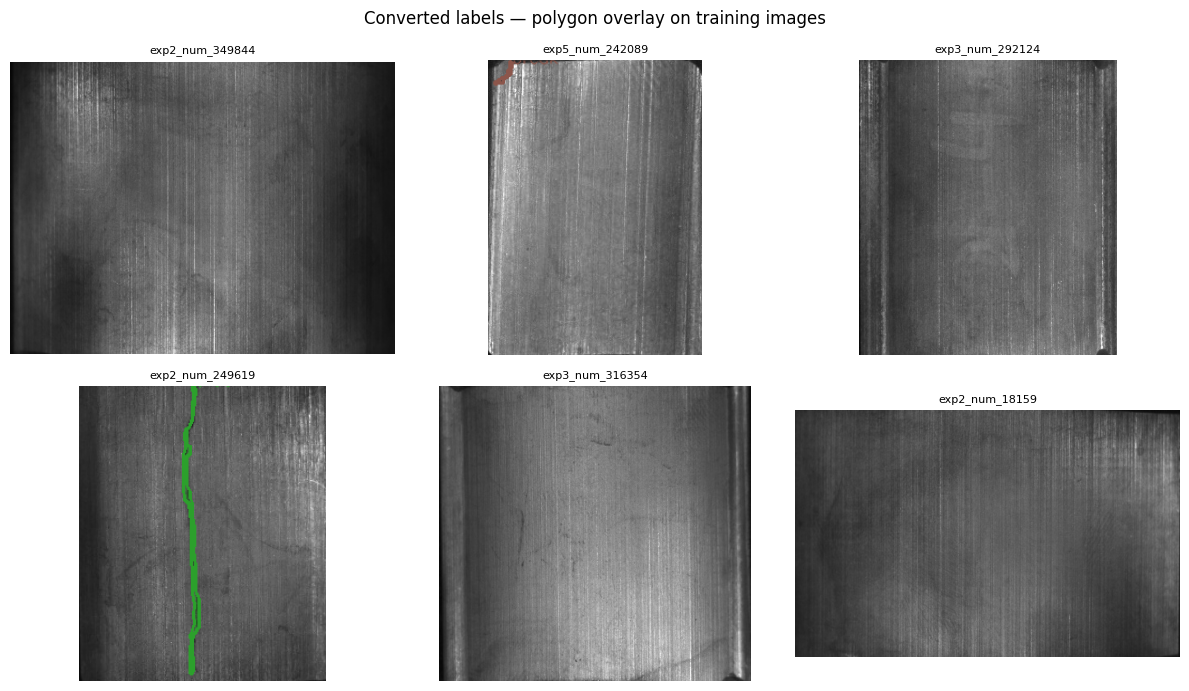

In [11]:
def render_yolo_seg_label(img_path: Path, label_path: Path) -> np.ndarray:
    """Render YOLO-seg polygon labels on an image. Returns RGB array."""
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if not label_path.exists():
        return img
    for line in label_path.read_text().strip().splitlines():
        parts  = line.split()
        cls_id = int(parts[0])
        coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
        coords = (coords * [w, h]).astype(int)
        color  = tuple((np.array(COLORS[cls_id][:3]) * 255).astype(int).tolist())
        cv2.polylines(img, [coords], isClosed=True, color=color, thickness=2)
        # Semi-transparent fill
        overlay = img.copy()
        cv2.fillPoly(overlay, [coords], color)
        img = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)
        # Class label
        cv2.putText(img, DEFECT_CLASSES[cls_id],
                    tuple(coords[0]), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, color, 1, cv2.LINE_AA)
    return img

# Show 6 random training images with their converted labels
train_imgs = list((OUTPUT_ROOT / "train" / "images").glob("*.jpg"))
samples    = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle("Converted labels — polygon overlay on training images", fontsize=12)
for ax, img_path in zip(axes.flatten(), samples):
    lbl_path = OUTPUT_ROOT / "train" / "labels" / (img_path.stem + ".txt")
    rendered = render_yolo_seg_label(img_path, lbl_path)
    ax.imshow(rendered)
    ax.set_title(img_path.stem[:20], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

#### **Verify the source of images**

**Note:** One can see that some of the above images does not show any label, because they simply belong to the defect-free class. Run the following cell to verfiy where the image comes from

In [15]:
# Find which class folder this image actually came from
stem = "exp3_num_316354"  # This code can be changed according to the displayed image above

for folder in CLASS_FOLDERS + [FREE_FOLDER]:
    img_dir = DATASET_ROOT / folder / "Imgs"
    jpg = img_dir / f"{stem}.jpg"
    png = img_dir / f"{stem}.png"
    print(f"{folder:15s}  jpg={jpg.exists()}  png={png.exists()}")

MT_Blowhole      jpg=False  png=False
MT_Crack         jpg=False  png=False
MT_Break         jpg=False  png=False
MT_Fray          jpg=False  png=False
MT_Uneven        jpg=False  png=False
MT_Free          jpg=True  png=True


In [17]:
# Check all 6 images from the verification plot
stems = [
    "Fill in the image title here",
    "Fill in the image title here",
    "Fill in the image title here",
    "Fill in the image title here",
    "Fill in the image title here",
    "Fill in the image title here",
]

print(f"{'Stem':<25} {'Class':>15}  {'Has mask':>10}")
print("─" * 55)
for stem in stems:
    found_folder = None
    has_mask     = False
    for folder in CLASS_FOLDERS + [FREE_FOLDER]:
        img_dir = DATASET_ROOT / folder / "Imgs"
        if (img_dir / f"{stem}.jpg").exists():
            found_folder = folder
            has_mask     = (img_dir / f"{stem}.png").exists()
            break
    print(f"{stem:<25} {str(found_folder):>15}  {str(has_mask):>10}")

Stem                                Class    Has mask
───────────────────────────────────────────────────────
exp4_num_286277                   MT_Free        True
exp3_num_258558                   MT_Fray        True
exp5_num_354439                   MT_Free        True
exp3_num_332719                   MT_Free        True
exp6_num_355732                   MT_Free        True
exp3_num_342176                  MT_Crack        True


### 2.5 Write `data.yaml`

In [14]:
cfg = {
    "path" : str(OUTPUT_ROOT.resolve()),
    "train": "train/images",
    "val"  : "val/images",
    "nc"   : NC,
    "names": DEFECT_CLASSES,
}
with open(YAML_PATH, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False)

print("data.yaml written:")
print(YAML_PATH.read_text())

data.yaml written:
names:
- blowhole
- crack
- break
- fray
- uneven
nc: 5
path: /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Segmentation/magnetic_tile_yolo
train: train/images
val: val/images



## 3. Training

We fine-tune **YOLO11n-seg** starting from COCO pretrained weights.  
The `-seg` suffix means the model has an additional **mask head** on top of the detection head — it predicts 32 prototype masks and a set of coefficients per detection to linearly combine them into the final instance mask.

**While training runs**, the key conceptual point to absorb: the segmentation head adds `seg_loss` on top of the detection `box_loss` and `cls_loss`. The model is jointly optimised to get boxes right *and* masks right — these two objectives sometimes pull in different directions, which is why `box/mAP` and `seg/mAP` can diverge.

In [15]:
YOLO_WEIGHTS = Path("/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Segmentation/yolo11n-seg.pt")

In [16]:
model = YOLO(str(YOLO_WEIGHTS)) 

results = model.train(
    data     = str(YAML_PATH),
    epochs   = 30,
    imgsz    = 640,
    batch    = 16,
    device   = DEVICE,
    workers  = 2,
    patience = 10,
    max_det  = 50,      # magnetic tiles rarely have >10 defects; cap saves NMS time
    seed     = SEED,
    project = str(FLASH_DIR / "runs/segment"),
    name     = "magnetic_tile_yolo11n",
    exist_ok = True,
)

#RUN_DIR = Path(results.save_dir)
print(f"\nTraining complete. Outputs saved to: {RUN_DIR}")

New https://pypi.org/project/ultralytics/8.4.164 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.12.3 torch-2.9.1+rocm6.4 CUDA:0 (AMD Instinct MI250X, 65520MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Segmentation/magnetic_tile_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=50, mixup=0.0, mode=train, m

### 3.1 Training curves

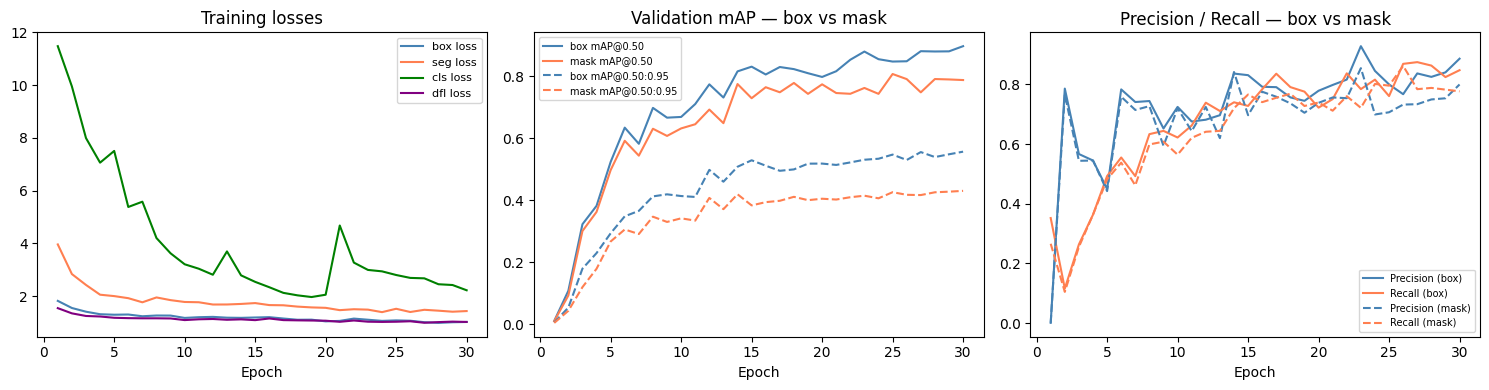

In [14]:
import pandas as pd

df = pd.read_csv(RUN_DIR / "results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── losses ──────────────────────────────────────────────────────────────────
loss_cols = {
    "train/box_loss" : ("box loss",  "steelblue"),
    "train/seg_loss" : ("seg loss",  "coral"),
    "train/cls_loss" : ("cls loss",  "green"),
    "train/dfl_loss" : ("dfl loss",  "purple"),
}
for col, (label, color) in loss_cols.items():
    if col in df.columns:
        axes[0].plot(df["epoch"], df[col], label=label, color=color)
axes[0].set_title("Training losses")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8)

# ── box mAP vs seg mAP ──────────────────────────────────────────────────────
map_cols = {
    "metrics/mAP50(B)"   : ("box mAP@0.50",     "steelblue"),
    "metrics/mAP50(M)"   : ("mask mAP@0.50",    "coral"),
    "metrics/mAP50-95(B)": ("box mAP@0.50:0.95", "steelblue"),
    "metrics/mAP50-95(M)": ("mask mAP@0.50:0.95","coral"),
}
styles = ["-", "-", "--", "--"]
for (col, (label, color)), ls in zip(map_cols.items(), styles):
    if col in df.columns:
        axes[1].plot(df["epoch"], df[col], label=label, color=color,
                     linestyle=ls)
axes[1].set_title("Validation mAP — box vs mask")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=7)

# ── precision / recall ──────────────────────────────────────────────────────
for col, label, color in [
    ("metrics/precision(B)", "Precision (box)",  "steelblue"),
    ("metrics/recall(B)",    "Recall (box)",     "coral"),
    ("metrics/precision(M)", "Precision (mask)", "steelblue"),
    ("metrics/recall(M)",    "Recall (mask)",    "coral"),
]:
    ls = "-" if "(B)" in col else "--"
    if col in df.columns:
        axes[2].plot(df["epoch"], df[col], label=label, color=color,
                     linestyle=ls)
axes[2].set_title("Precision / Recall — box vs mask")
axes[2].set_xlabel("Epoch")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

**Discussion**: Is `mask mAP@0.50` higher or lower than `box mAP@0.50`? For magnetic tile defects, the mask IoU threshold is harder to satisfy than box IoU — a box that roughly contains a thin crack scores IoU 0.50 easily, but a mask must match the crack pixel-by-pixel to pass the same threshold.

## 4. Evaluation

### 4.1 Per-class box mAP and mask mAP

In [24]:
best_weights = RUN_DIR / "weights" / "best.pt"
model_eval   = YOLO(str(best_weights))

val_results = model_eval.val(
    data    = str(YAML_PATH),
    split   = "val",
    device  = DEVICE,
    verbose = False,
)

box_ap50  = val_results.box.ap50          # per-class box AP@50  (shape: NC,)
mask_ap50 = val_results.seg.ap50          # per-class mask AP@50

# Overall metrics
print(f"Box  mAP@0.50      : {val_results.box.map50:.4f}")
print(f"Box  mAP@0.50:0.95 : {val_results.box.map:.4f}")
print(f"Mask mAP@0.50      : {val_results.seg.map50:.4f}")
print(f"Mask mAP@0.50:0.95 : {val_results.seg.map:.4f}")
print()
print(f"{'Class':<12} {'Box AP@50':>12} {'Mask AP@50':>12}")
print("─" * 38)
for name, b, m in zip(DEFECT_CLASSES,
                       val_results.box.ap50,
                       val_results.seg.ap50):
    print(f"{name:<12} {b:>12.4f} {m:>12.4f}")

Ultralytics 8.4.7 🚀 Python-3.12.3 torch-2.9.1+rocm6.4 CUDA:0 (AMD Instinct MI250X, 65520MiB)
YOLO11n-seg summary (fused): 114 layers, 2,835,543 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.0 ms, read: 92.0±64.2 MB/s, size: 36.3 KB)
val: Scanning /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Segmentation/magnetic_tile_yolo/val/labels.cache... 56 images, 538 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 594/594 249.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 18.2it/s 2.1s0.1s
                   all        594         69      0.848      0.828      0.889      0.558      0.751       0.78      0.779      0.428
Speed: 0.7ms preprocess, 1.2ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /pfs/lustrep4/users/xieruiwe/YOLO_1001_test/runs/segment/val3
Box  mAP@0.50      : 0.8886
Box  

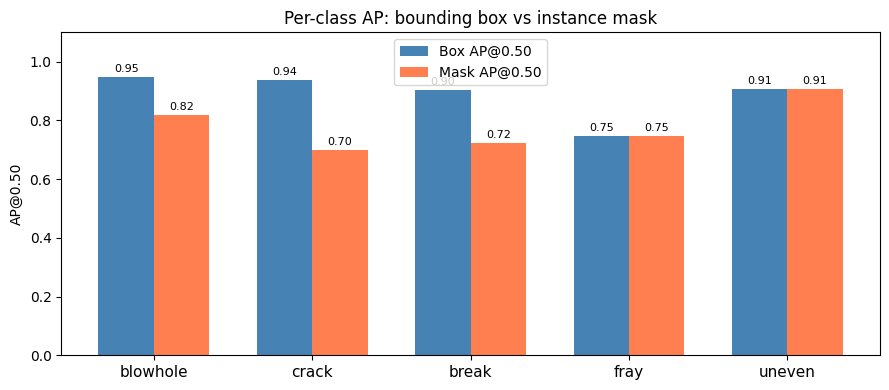

In [9]:
# Side-by-side bar chart: box AP vs mask AP per class
x     = np.arange(NC)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - width/2, val_results.box.ap50, width,
            label="Box AP@0.50",  color="steelblue")
b2 = ax.bar(x + width/2, val_results.seg.ap50, width,
            label="Mask AP@0.50", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(DEFECT_CLASSES, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("AP@0.50")
ax.set_title("Per-class AP: bounding box vs instance mask")
ax.legend()
ax.bar_label(b1, fmt="%.2f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

**Discussion**: For which classes is the gap between box AP and mask AP largest? A large gap means the model finds the defect (good box) but struggles to draw its precise boundary (poor mask). This is most pronounced for defects with irregular or thin shapes.

### 4.2 Qualitative results — GT mask vs predicted mask

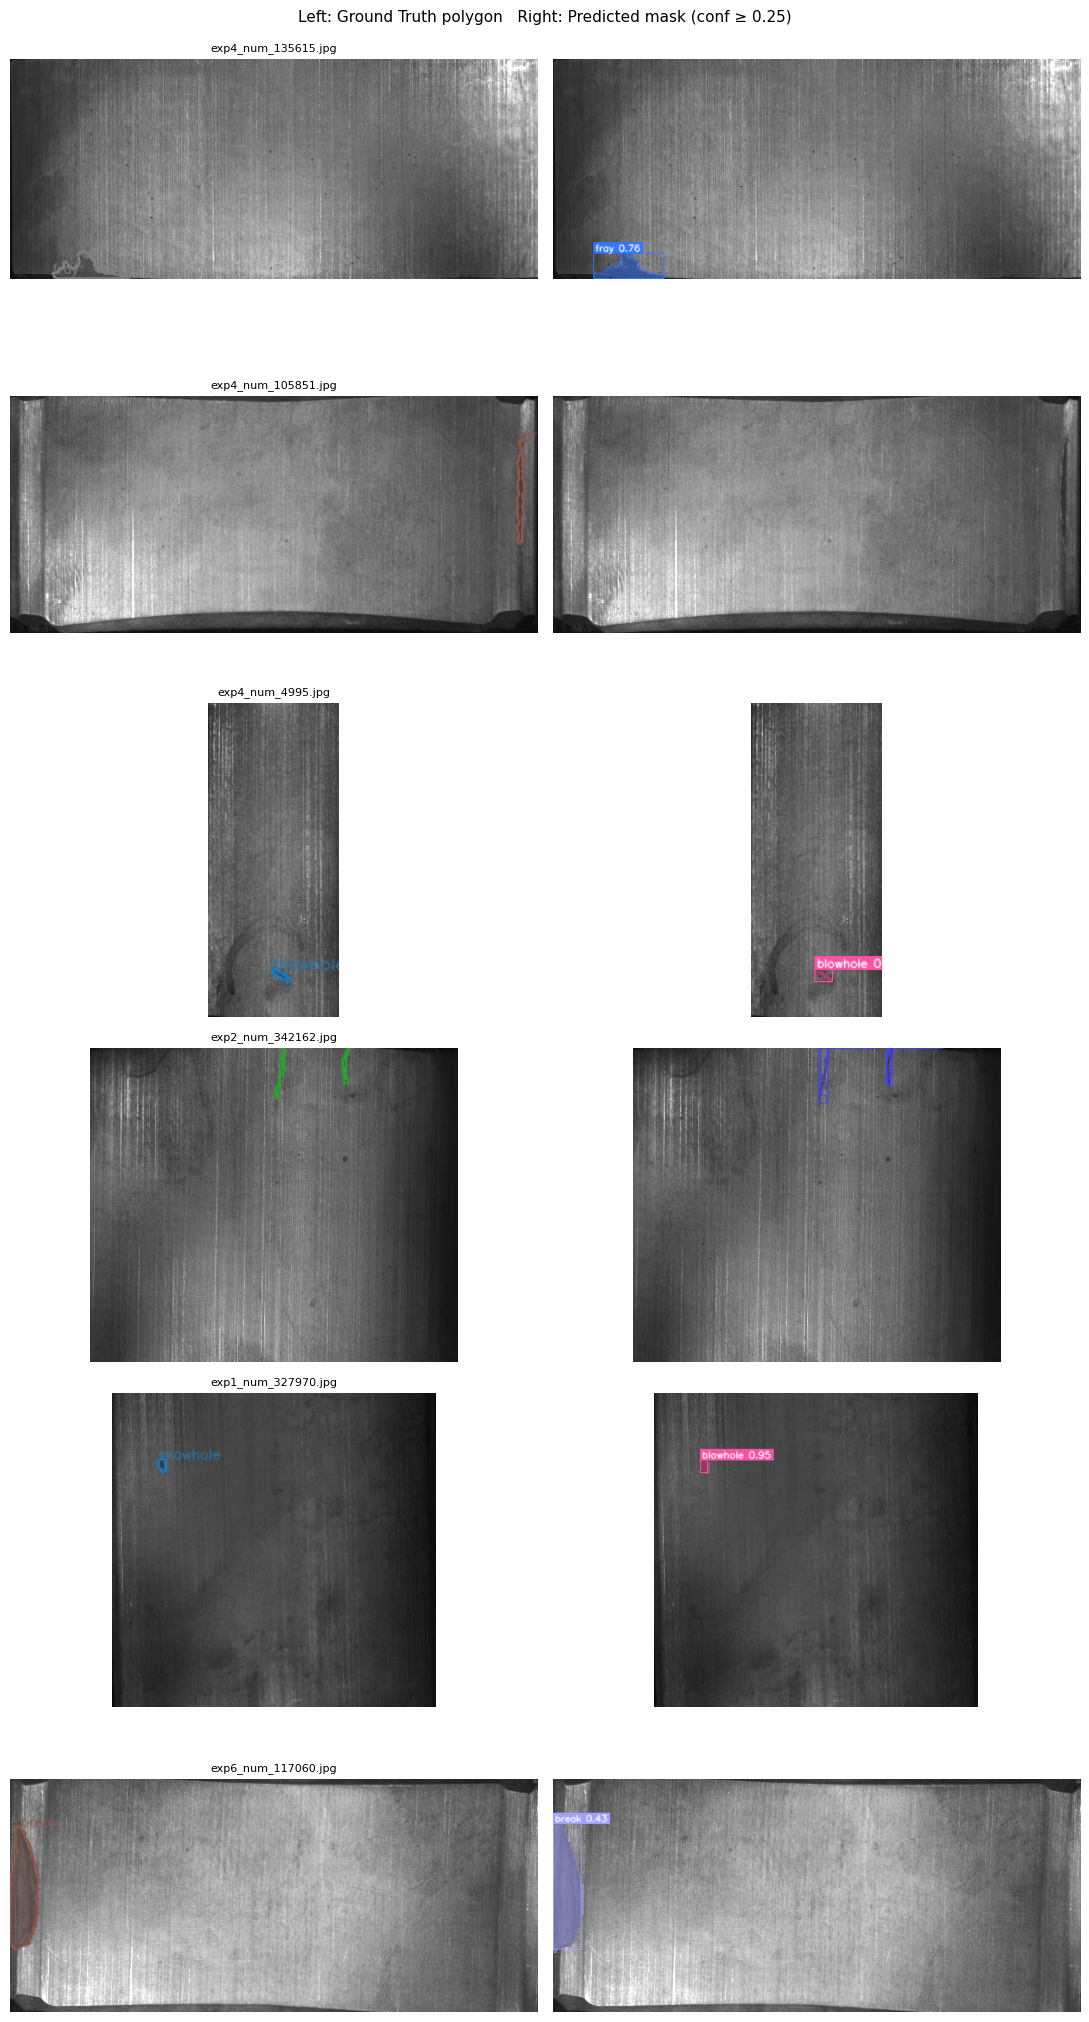

In [12]:
CONF_THRESHOLD = 0.25

#val_imgs = list((OUTPUT_ROOT / "val" / "images").glob("*.jpg"))
#samples  = random.sample(val_imgs, min(6, len(val_imgs)))

# Only sample images that have a corresponding label file
val_label_dir = OUTPUT_ROOT / "val" / "labels"
val_imgs_with_labels = [
    OUTPUT_ROOT / "val" / "images" / (lf.stem + ".jpg")
    for lf in val_label_dir.glob("*.txt")
    if (OUTPUT_ROOT / "val" / "images" / (lf.stem + ".jpg")).exists()
]
samples = random.sample(val_imgs_with_labels, min(6, len(val_imgs_with_labels)))

mask_ann  = sv.MaskAnnotator(opacity=0.5)
box_ann   = sv.BoxAnnotator(thickness=1)
label_ann = sv.LabelAnnotator(text_scale=0.35, text_padding=2)

fig, axes = plt.subplots(len(samples), 2,
                          figsize=(11, 3.5 * len(samples)))
fig.suptitle(
    f"Left: Ground Truth polygon   Right: Predicted mask (conf ≥ {CONF_THRESHOLD})",
    fontsize=11)

for row, img_path in enumerate(samples):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ── ground truth (polygon rendered back) ────────────────────────────
    lbl_path = OUTPUT_ROOT / "val" / "labels" / (img_path.stem + ".txt")
    gt_img   = render_yolo_seg_label(img_path, lbl_path)

    # ── prediction ──────────────────────────────────────────────────────
    pred     = model_eval.predict(str(img_path), conf=CONF_THRESHOLD, max_det = 50,
                                  device=DEVICE, verbose=False)[0]
    pred_img = img_rgb.copy()
    if len(pred.boxes) and pred.masks is not None:
        det  = sv.Detections.from_ultralytics(pred)
        lbls = [f"{DEFECT_CLASSES[c]} {s:.2f}"
                for c, s in zip(det.class_id, det.confidence)]
        pred_img = mask_ann.annotate(pred_img.copy(), det)
        pred_img = box_ann.annotate(pred_img, det)
        pred_img = label_ann.annotate(pred_img, det, lbls)

    axes[row][0].imshow(gt_img);   axes[row][0].axis("off")
    axes[row][1].imshow(pred_img); axes[row][1].axis("off")
    axes[row][0].set_title(img_path.name[:25], fontsize=8)

plt.tight_layout()
plt.show()

### 4.3 The class imbalance effect revisited

We predicted in Section 1.1 that rarer classes would perform worse. Let's check that explicitly.

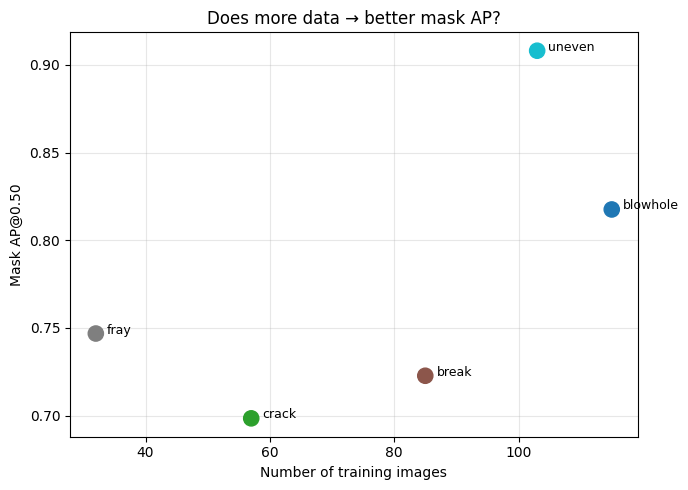

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
class_img_counts = [counts[n] for n in DEFECT_CLASSES]
mask_aps         = list(val_results.seg.ap50)

scatter = ax.scatter(class_img_counts, mask_aps,
                     c=range(NC), cmap="tab10", s=120, zorder=3)
for i, name in enumerate(DEFECT_CLASSES):
    ax.annotate(name, (class_img_counts[i], mask_aps[i]),
                textcoords="offset points", xytext=(8, 0), fontsize=9)
ax.set_xlabel("Number of training images")
ax.set_ylabel("Mask AP@0.50")
ax.set_title("Does more data → better mask AP?")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Discussion**: Is there a clear correlation between training image count and mask AP? If not, what else might explain the per-class performance differences? (Consider: defect complexity, visual contrast, defect size, within-class variation.)

### 4.4 Confidence threshold exploration

Weakest class: 'crack'
Found 8 val images with 'crack'
Selected: exp3_num_249637.jpg  (normalised defect area: 0.0629)


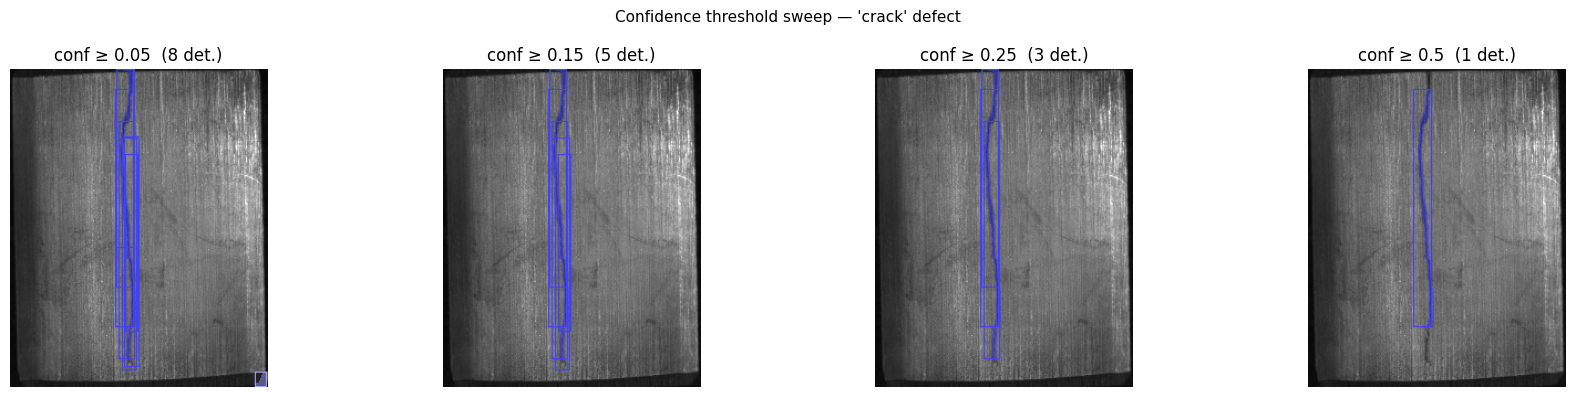

In [17]:
# Pick the weakest class and show effect of lowering the threshold
worst_cls_id   = int(np.argmin(list(val_results.seg.ap50)))
worst_cls_name = DEFECT_CLASSES[worst_cls_id]
print(f"Weakest class: '{worst_cls_name}'")

# Find ALL val images containing this class, then pick the one
# with the largest defect area (most visually informative)
val_lbl_dir = OUTPUT_ROOT / "val" / "labels"
val_img_dir = OUTPUT_ROOT / "val" / "images"

candidates = []
for lf in val_lbl_dir.glob("*.txt"):
    total_area = 0
    has_class  = False
    for line in lf.read_text().strip().splitlines():
        if not line:
            continue
        parts = line.split()
        if int(parts[0]) == worst_cls_id:
            has_class = True
            # approximate polygon area as bounding box of its points
            coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
            w = coords[:, 0].max() - coords[:, 0].min()
            h = coords[:, 1].max() - coords[:, 1].min()
            total_area += w * h
    if has_class:
        img_path = next(
            (val_img_dir / f"{lf.stem}{ext}" for ext in [".jpg", ".png"]
             if (val_img_dir / f"{lf.stem}{ext}").exists()), None)
        if img_path:
            candidates.append((total_area, img_path))

# Pick the image with the largest defect area — most likely to show clear masks
candidates.sort(reverse=True)
worst_img = candidates[0][1] if candidates else None
print(f"Found {len(candidates)} val images with '{worst_cls_name}'")
if candidates:
    print(f"Selected: {worst_img.name}  (normalised defect area: {candidates[0][0]:.4f})")

if worst_img:
    thresholds = [0.05, 0.15, 0.25, 0.50]
    fig, axes  = plt.subplots(1, len(thresholds),
                               figsize=(4.5 * len(thresholds), 4))
    fig.suptitle(f"Confidence threshold sweep — '{worst_cls_name}' defect",
                 fontsize=11)

    for ax, thr in zip(axes, thresholds):
        pred = model_eval.predict(
            str(worst_img),
            conf    = thr,
            device  = DEVICE,
            verbose = False,
            max_det = 50,      # ← fixes NMS time limit warning
        )[0]
        img_rgb = cv2.cvtColor(cv2.imread(str(worst_img)), cv2.COLOR_BGR2RGB)
        if len(pred.boxes) and pred.masks is not None:
            det     = sv.Detections.from_ultralytics(pred)
            img_rgb = mask_ann.annotate(img_rgb.copy(), det)
            img_rgb = box_ann.annotate(img_rgb, det)
        n = len(pred.boxes)
        ax.imshow(img_rgb)
        ax.set_title(f"conf ≥ {thr}  ({n} det.)")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"No val image found for class '{worst_cls_name}'")

**Compare with the output below**

Weakest class: 'crack'
Found 8 val images with 'crack'
Selected: exp3_num_249637.jpg  (normalised defect area: 0.0629)


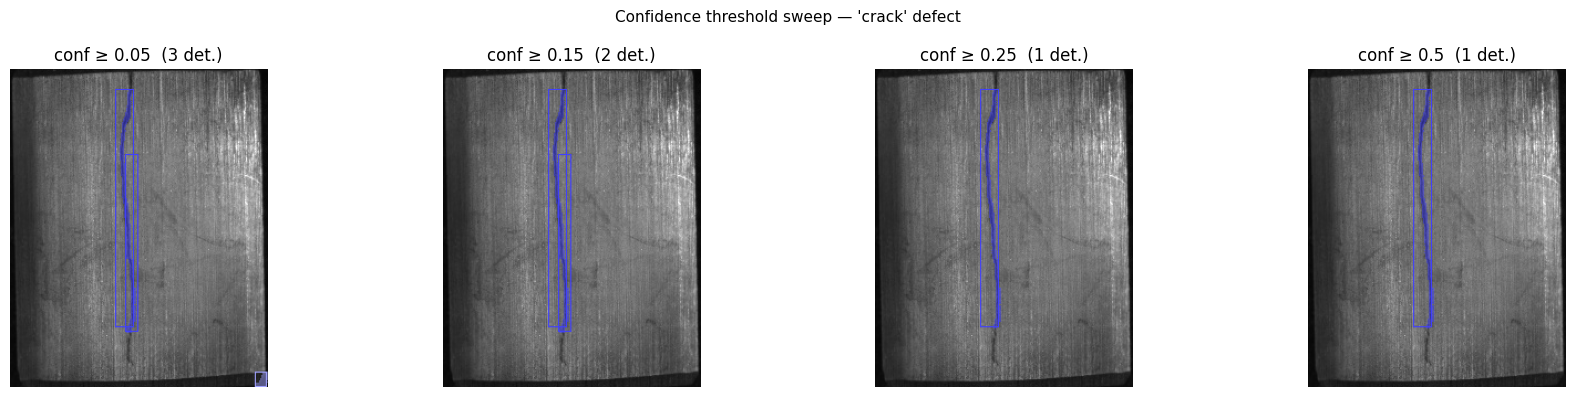

In [18]:
# Pick the weakest class and show effect of lowering the threshold
worst_cls_id   = int(np.argmin(list(val_results.seg.ap50)))
worst_cls_name = DEFECT_CLASSES[worst_cls_id]
print(f"Weakest class: '{worst_cls_name}'")

# Find ALL val images containing this class, then pick the one
# with the largest defect area (most visually informative)
val_lbl_dir = OUTPUT_ROOT / "val" / "labels"
val_img_dir = OUTPUT_ROOT / "val" / "images"

candidates = []
for lf in val_lbl_dir.glob("*.txt"):
    total_area = 0
    has_class  = False
    for line in lf.read_text().strip().splitlines():
        if not line:
            continue
        parts = line.split()
        if int(parts[0]) == worst_cls_id:
            has_class = True
            # approximate polygon area as bounding box of its points
            coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
            w = coords[:, 0].max() - coords[:, 0].min()
            h = coords[:, 1].max() - coords[:, 1].min()
            total_area += w * h
    if has_class:
        img_path = next(
            (val_img_dir / f"{lf.stem}{ext}" for ext in [".jpg", ".png"]
             if (val_img_dir / f"{lf.stem}{ext}").exists()), None)
        if img_path:
            candidates.append((total_area, img_path))

# Pick the image with the largest defect area — most likely to show clear masks
candidates.sort(reverse=True)
worst_img = candidates[0][1] if candidates else None
print(f"Found {len(candidates)} val images with '{worst_cls_name}'")
if candidates:
    print(f"Selected: {worst_img.name}  (normalised defect area: {candidates[0][0]:.4f})")

if worst_img:
    thresholds = [0.05, 0.15, 0.25, 0.50]
    fig, axes  = plt.subplots(1, len(thresholds),
                               figsize=(4.5 * len(thresholds), 4))
    fig.suptitle(f"Confidence threshold sweep — '{worst_cls_name}' defect",
                 fontsize=11)

    for ax, thr in zip(axes, thresholds):
        pred = model_eval.predict(
            str(worst_img),
            conf    = thr,
            device  = DEVICE,
            verbose = False,
            max_det = 50,      # ← fixes NMS time limit warning
            iou          = 0.3,
            agnostic_nms = True   # collapses cross-class duplicates on the same crack
        )[0]
        img_rgb = cv2.cvtColor(cv2.imread(str(worst_img)), cv2.COLOR_BGR2RGB)
        if len(pred.boxes) and pred.masks is not None:
            det     = sv.Detections.from_ultralytics(pred)
            img_rgb = mask_ann.annotate(img_rgb.copy(), det)
            img_rgb = box_ann.annotate(img_rgb, det)
        n = len(pred.boxes)
        ax.imshow(img_rgb)
        ax.set_title(f"conf ≥ {thr}  ({n} det.)")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"No val image found for class '{worst_cls_name}'")

In [19]:
pred_debug = model_eval.predict(
    str(worst_img), conf=0.15, device=DEVICE, verbose=False,
    max_det=50, iou=0.3, agnostic_nms=True
)[0]

h, w = pred_debug.orig_shape
print(f"{'#':<4} {'Class':<10} {'Conf':>6}  {'y1':>6} {'y2':>6}  {'height':>8}")
print("─" * 44)
for i, (cls, conf, box) in enumerate(zip(
        pred_debug.boxes.cls.int().tolist(),
        pred_debug.boxes.conf.tolist(),
        pred_debug.boxes.xyxy.tolist())):
    x1, y1, x2, y2 = [int(v) for v in box]
    print(f"{i:<4} {DEFECT_CLASSES[cls]:<10} {conf:>6.3f}  "
          f"{y1:>6} {y2:>6}  {(y2-y1):>8}px")

#    Class        Conf      y1     y2    height
────────────────────────────────────────────
0    crack       0.726      18    233       215px
1    crack       0.228      77    237       160px


## 5. Failure Analysis

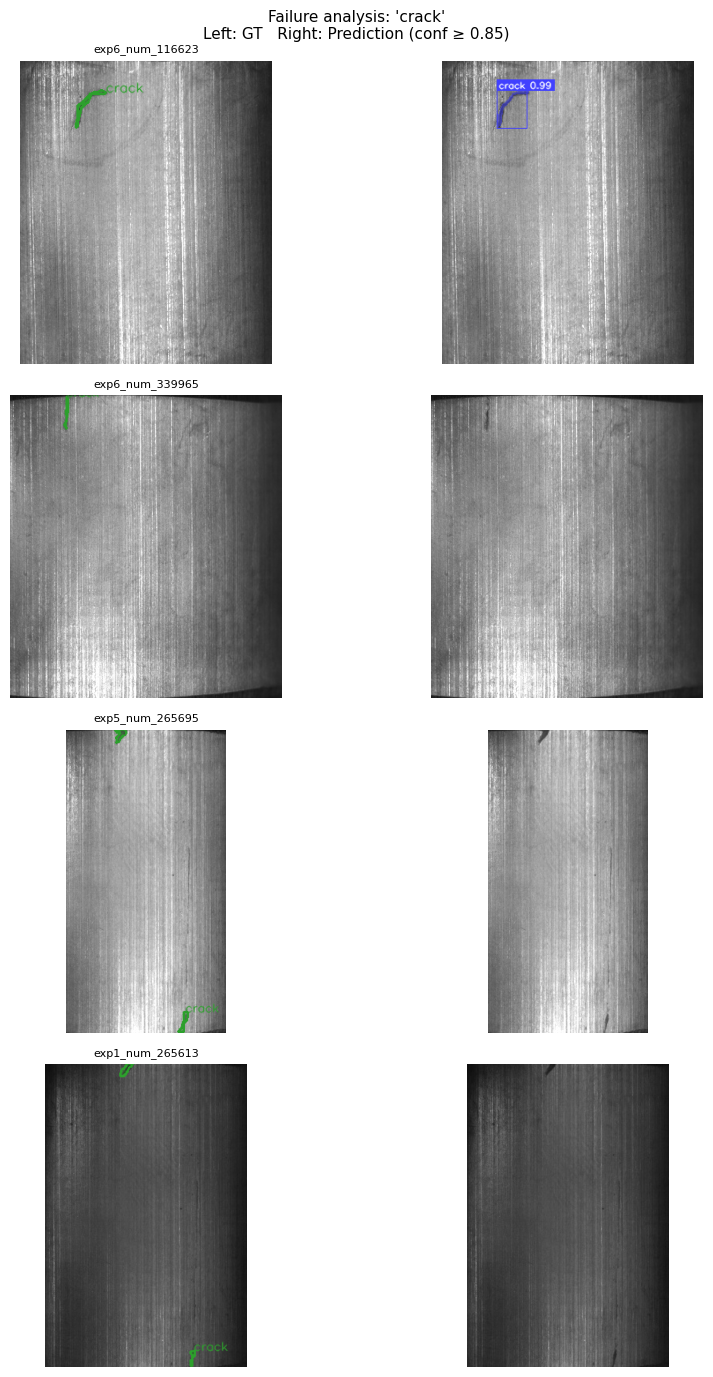

In [20]:
# Show GT vs prediction for the weakest class specifically
worst_stems = []
for lf in val_lbl_dir.glob("*.txt"):
    for line in lf.read_text().strip().splitlines():
        if line and int(line.split()[0]) == worst_cls_id:
            worst_stems.append(lf.stem)
            break

show_stems = random.sample(worst_stems, min(4, len(worst_stems)))
fig, axes  = plt.subplots(len(show_stems), 2,
                           figsize=(10, 3.5 * len(show_stems)))
fig.suptitle(
    f"Failure analysis: '{worst_cls_name}'\nLeft: GT   Right: Prediction (conf ≥ 0.85)",
    fontsize=11)

for row, stem in enumerate(show_stems):
    img_path = next(
        (val_img_dir / f"{stem}{ext}" for ext in [".jpg", ".png"]
         if (val_img_dir / f"{stem}{ext}").exists()), None)
    if img_path is None:
        continue

    lbl_path = val_lbl_dir / f"{stem}.txt"
    gt_img   = render_yolo_seg_label(img_path, lbl_path)

    pred     = model_eval.predict(str(img_path), conf=0.85,
                                  device=DEVICE, verbose=False)[0]
    pred_img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    if len(pred.boxes) and pred.masks is not None:
        det      = sv.Detections.from_ultralytics(pred)
        pred_img = mask_ann.annotate(pred_img.copy(), det)
        pred_img = box_ann.annotate(pred_img, det)
        pred_img = label_ann.annotate(pred_img, det,
            [f"{DEFECT_CLASSES[c]} {s:.2f}"
             for c, s in zip(det.class_id, det.confidence)])

    axes[row][0].imshow(gt_img);   axes[row][0].axis("off")
    axes[row][1].imshow(pred_img); axes[row][1].axis("off")
    axes[row][0].set_title(stem[:25], fontsize=8)

plt.tight_layout()
plt.show()

**Discussion**:
- Are missed defects consistently small, low-contrast, or at image edges?
- Does the model confuse any two defect types? (Check the predicted class labels)
- What would you do with 3 more months and a GPU cluster to improve the weakest class?

## 6. What Segmentation Adds Over Detection

Now that we have pixel masks, we can compute things that bounding boxes cannot provide.

In [21]:
# Defect area measurement from predicted masks
# Pick a few val images and report: class, pixel area, percentage of image covered
val_imgs = list((OUTPUT_ROOT / "val" / "images").glob("*.jpg"))
sample_imgs = random.sample(
    list((OUTPUT_ROOT / "val" / "images").glob("*.jpg")), min(8, len(val_imgs))
)

print(f"{'Image':<30} {'Class':>12} {'Conf':>6} {'Area (px²)':>12} {'Coverage':>10}")
print("─" * 74)

for img_path in sample_imgs:
    pred = model_eval.predict(str(img_path), conf=0.25,
                              device=DEVICE, verbose=False)[0]
    if not len(pred.boxes) or pred.masks is None:
        continue
    h, w = pred.orig_shape
    for i, (cls_id, conf, mask_data) in enumerate(
            zip(pred.boxes.cls.int().tolist(),
                pred.boxes.conf.tolist(),
                pred.masks.data.cpu().numpy())):
        # mask_data is binary (0/1) at model resolution; resize to original
        mask_full = cv2.resize(mask_data, (w, h),
                               interpolation=cv2.INTER_NEAREST)
        area      = int(mask_full.sum())
        coverage  = area / (h * w) * 100
        print(f"{img_path.name[:28]:<30} "
              f"{DEFECT_CLASSES[cls_id]:>12} "
              f"{conf:>6.2f} "
              f"{area:>12,d} "
              f"{coverage:>9.2f}%")

Image                                 Class   Conf   Area (px²)   Coverage
──────────────────────────────────────────────────────────────────────────
exp3_num_328014.jpg                blowhole   0.77          124      0.10%


**This is what a bounding box cannot give you.** In a real factory pipeline, this pixel-level area measurement feeds directly into:
- **Severity scoring**: is the defect coverage > 1% of tile area? Flag for rejection.
- **Trend monitoring**: is the average defect area increasing over the production shift?
- **Root cause analysis**: are defects appearing in specific spatial regions of the tile?

## 7. Wrap-up and Forward Pointer

### Summary

In [22]:
print("=" * 45)
print("  Afternoon session results summary")
print("=" * 45)
print(f"  Model    : YOLO11n-seg (pretrained COCO)")
print(f"  Dataset  : Magnetic Tile ({NC} defect classes)")
print()
print(f"  Box  mAP@0.50      : {val_results.box.map50:.4f}")
print(f"  Mask mAP@0.50      : {val_results.seg.map50:.4f}")
print(f"  Box  mAP@0.50:0.95 : {val_results.box.map:.4f}")
print(f"  Mask mAP@0.50:0.95 : {val_results.seg.map:.4f}")
print()
print("  Per-class Mask AP@0.50:")
for name, ap in zip(DEFECT_CLASSES, val_results.seg.ap50):
    bar = "█" * int(ap * 20)
    print(f"    {name:<12} {ap:.3f}  {bar}")
print("=" * 45)

  Afternoon session results summary
  Model    : YOLO11n-seg (pretrained COCO)
  Dataset  : Magnetic Tile (5 defect classes)

  Box  mAP@0.50      : 0.8886
  Mask mAP@0.50      : 0.7787
  Box  mAP@0.50:0.95 : 0.5583
  Mask mAP@0.50:0.95 : 0.4282

  Per-class Mask AP@0.50:
    blowhole     0.818  ████████████████
    crack        0.698  █████████████
    break        0.723  ██████████████
    fray         0.747  ██████████████
    uneven       0.908  ██████████████████


### The remaining open problem

Both today's sessions assumed **labelled defect examples** were available for training. In many real industrial settings, you have thousands of images of *good* tiles but only a handful of *defective* ones — not enough to train a supervised detector.

This motivates **anomaly detection**: train only on defect-free images, learn what "normal" looks like, and flag anything that deviates. The state-of-the-art method for this is **PatchCore** (Roth et al., 2022), which:
1. Extracts patch-level features from a pretrained backbone on normal images only
2. Builds a memory bank of normal patch features
3. At test time, flags patches whose features are far from the memory bank

PatchCore achieves near-perfect AUROC on the MVTec dataset — using *zero defect labels*. The Magnetic Tile `MT_Free` folder (which we used only as background today) is exactly the kind of data PatchCore trains on.

That is a natural next step beyond today's supervised segmentation.